# 🎯 Probability Calibration Checker

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/ml-engineering-toolkit/calibration-checker/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=ml-engineering-toolkit/calibration-checker/demo.ipynb)

> A "0.9" from your model should mean it happens 90% of the time. Often it doesn't.

**Pain point:** *"Our probabilities are meaningless."* A model can rank cases perfectly
(great AUC) while its raw scores are systematically over- or under-confident. This
notebook measures that with a **reliability curve**, the **Brier score**, and
**Expected Calibration Error (ECE)**, then fixes it with **Platt (sigmoid)** and
**isotonic** recalibration.

## Table of contents
1. [Setup](#1-setup)
2. [Build the data](#2-build-the-data)
3. [Fit three models](#3-fit-three-models)
4. [Score them (Brier / log-loss / AUC / ECE)](#4-score-them)
5. [Reliability diagram](#5-reliability-diagram)
6. [Bar chart: Brier & ECE across models](#6-bar-chart)
7. [Try your own](#7-try-your-own)

This notebook is **standalone** - it duplicates the core logic and imports nothing
from `calibration.py`.


## 1. Setup

In [1]:
from __future__ import annotations

from typing import Optional, List, Dict, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import brier_score_loss, log_loss, roc_auc_score

SEED = 42
np.random.seed(SEED)
print("libraries ready")

libraries ready


## 2. Build the data

Correlated / redundant features make `GaussianNB` violate its independence
assumption and become **over-confident** - a perfect calibration stress test.

In [2]:
def demo_data(seed: int = 42) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    X, y = make_classification(
        n_samples=6000, n_features=20, n_informative=6, n_redundant=8,
        n_clusters_per_class=2, weights=[0.7, 0.3], flip_y=0.05,
        class_sep=0.8, random_state=seed,
    )
    return train_test_split(X, y, test_size=0.4, random_state=seed, stratify=y)

X_train, X_test, y_train, y_test = demo_data(SEED)
print("train:", X_train.shape, " test:", X_test.shape)
print("positive rate (train): %.3f" % y_train.mean())

train: (3600, 20)  test: (2400, 20)
positive rate (train): 0.308


## 3. Fit three models

Same base learner (`GaussianNB`) three ways: raw, wrapped in **Platt (sigmoid)**
scaling, and wrapped in **isotonic** regression. `CalibratedClassifierCV` fits the
calibration map on held-out folds so it does not peek at its own training data.

In [3]:
def fit_models(X_tr: np.ndarray, y_tr: np.ndarray, seed: int = 42) -> Dict[str, object]:
    base = GaussianNB().fit(X_tr, y_tr)
    platt = CalibratedClassifierCV(GaussianNB(), method="sigmoid", cv=5).fit(X_tr, y_tr)
    isotonic = CalibratedClassifierCV(GaussianNB(), method="isotonic", cv=5).fit(X_tr, y_tr)
    return {"uncalibrated": base, "platt": platt, "isotonic": isotonic}

models = fit_models(X_train, y_train, SEED)
probs: Dict[str, np.ndarray] = {n: m.predict_proba(X_test)[:, 1] for n, m in models.items()}
print("fitted:", list(models.keys()))

fitted: ['uncalibrated', 'platt', 'isotonic']


## 4. Score them

`reliability_points` bins the predicted probabilities and, per bin, compares the
mean predicted probability (**confidence**) to the observed fraction of positives
(**accuracy**). **ECE** is the sample-weighted mean of that absolute gap. Lower
Brier / log-loss / ECE = better calibrated; AUC only measures ranking.

In [4]:
def reliability_points(y_true: np.ndarray, y_prob: np.ndarray,
                       n_bins: int = 10) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    y_true = np.asarray(y_true); y_prob = np.asarray(y_prob)
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_ids = np.clip(np.digitize(y_prob, bins[1:-1], right=False), 0, n_bins - 1)
    mp: List[float] = []; fp: List[float] = []; bc: List[int] = []
    for b in range(n_bins):
        mask = bin_ids == b
        count = int(mask.sum())
        if count == 0:
            continue
        mp.append(float(y_prob[mask].mean()))
        fp.append(float(y_true[mask].mean()))
        bc.append(count)
    return np.array(mp), np.array(fp), np.array(bc)

def expected_calibration_error(y_true: np.ndarray, y_prob: np.ndarray,
                               n_bins: int = 10) -> float:
    mp, fp, counts = reliability_points(y_true, y_prob, n_bins)
    if counts.sum() == 0:
        return float("nan")
    w = counts / counts.sum()
    return float(np.sum(w * np.abs(mp - fp)))

def evaluate(models: Dict[str, object], X_te: np.ndarray, y_te: np.ndarray,
             n_bins: int = 10) -> pd.DataFrame:
    rows: Dict[str, Dict[str, float]] = {}
    for name, model in models.items():
        p = model.predict_proba(X_te)[:, 1]
        rows[name] = {
            "brier": float(brier_score_loss(y_te, p)),
            "log_loss": float(log_loss(y_te, p, labels=[0, 1])),
            "roc_auc": float(roc_auc_score(y_te, p)),
            "ece": expected_calibration_error(y_te, p, n_bins),
        }
    return pd.DataFrame(rows).T[["brier", "log_loss", "roc_auc", "ece"]]

table = evaluate(models, X_test, y_test).sort_values("ece")
table.style.format("{:.4f}").background_gradient(subset=["brier", "ece"], cmap="RdYlGn_r")

,brier,log_loss,roc_auc,ece
isotonic,0.1284,0.4145,0.8563,0.0212
platt,0.1344,0.4310,0.8568,0.0438
uncalibrated,0.1495,0.5704,0.8566,0.1163


In [5]:
best = table.index[0]
print("Best calibrated by ECE: %s" % best)
print("  ECE   %.4f  (uncalibrated %.4f)" % (table.loc[best, "ece"], table.loc["uncalibrated", "ece"]))
print("  Brier %.4f  (uncalibrated %.4f)" % (table.loc[best, "brier"], table.loc["uncalibrated", "brier"]))
print("  AUC barely moves - ranking was never the problem; the probabilities were.")

Best calibrated by ECE: isotonic
  ECE   0.0212  (uncalibrated 0.1163)
  Brier 0.1284  (uncalibrated 0.1495)
  AUC barely moves - ranking was never the problem; the probabilities were.


## 5. Reliability diagram

The dashed diagonal is perfect calibration. Points **below** the line = the model
is **over-confident** (predicts higher probabilities than reality delivers); points
**above** = under-confident. The curve hugging the diagonal is best calibrated.

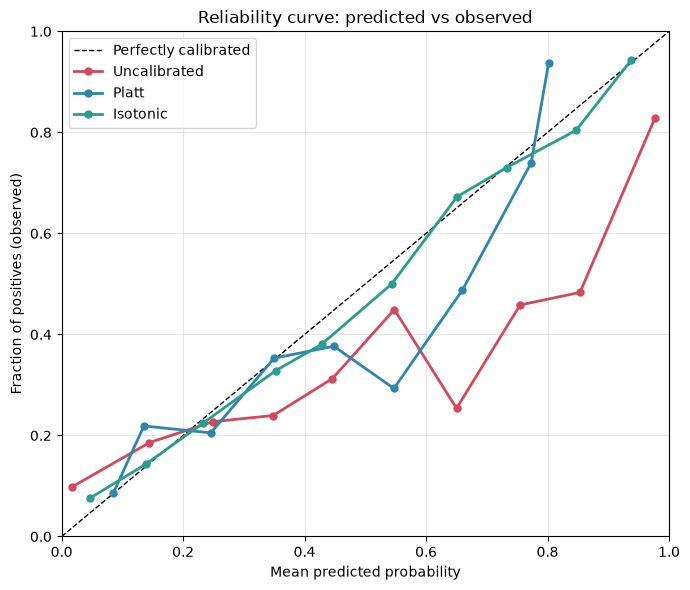

In [6]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Perfectly calibrated")
colors = {"uncalibrated": "#d1495b", "platt": "#2e86ab", "isotonic": "#2a9d8f"}
for name in ["uncalibrated", "platt", "isotonic"]:
    mp, fp, _ = reliability_points(y_test, probs[name], n_bins=10)
    ax.plot(mp, fp, marker="o", linewidth=2, markersize=5,
            color=colors[name], label=name.title())
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Fraction of positives (observed)")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_title("Reliability curve: predicted vs observed")
ax.legend(loc="upper left"); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Bar chart

Same story as a single number: Brier and ECE drop sharply after recalibration.

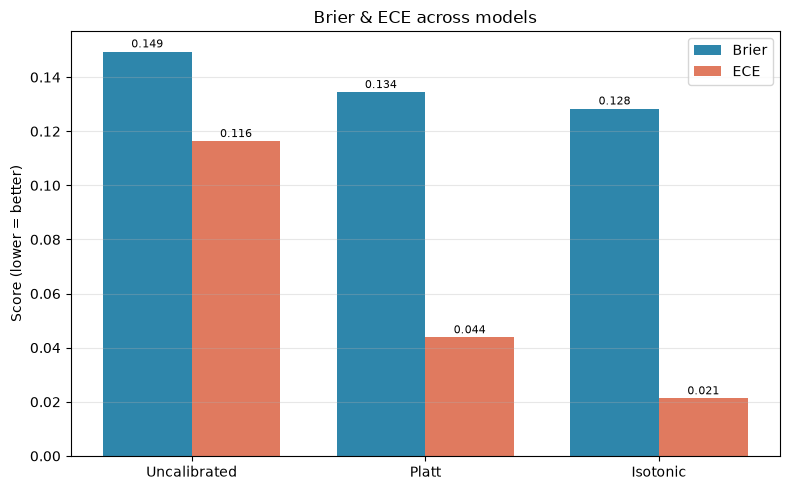

In [7]:
order = ["uncalibrated", "platt", "isotonic"]
sub = table.loc[order]
x = np.arange(len(order)); width = 0.38
fig, ax = plt.subplots(figsize=(8, 5))
b1 = ax.bar(x - width/2, sub["brier"], width, label="Brier", color="#2e86ab")
b2 = ax.bar(x + width/2, sub["ece"], width, label="ECE", color="#e07a5f")
ax.set_xticks(x); ax.set_xticklabels([o.title() for o in order])
ax.set_ylabel("Score (lower = better)")
ax.set_title("Brier & ECE across models")
ax.legend()
for bars in (b1, b2):
    for bar in bars:
        ax.annotate("%.3f" % bar.get_height(),
                    (bar.get_x() + bar.get_width()/2, bar.get_height()),
                    textcoords="offset points", xytext=(0, 3),
                    ha="center", fontsize=8)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Try your own

Swap in your own `X`, `y` (a held-out probability array from your classifier) and
re-run the scoring + plots. Uncomment below.

In [8]:
# --- Try Your Own -------------------------------------------------------
# from sklearn.ensemble import RandomForestClassifier
# my_X_train, my_X_test, my_y_train, my_y_test = demo_data(seed=7)
# my_models = {
#     "uncalibrated": RandomForestClassifier(max_depth=3, random_state=7).fit(my_X_train, my_y_train),
#     "platt": CalibratedClassifierCV(RandomForestClassifier(max_depth=3, random_state=7),
#                                     method="sigmoid", cv=5).fit(my_X_train, my_y_train),
#     "isotonic": CalibratedClassifierCV(RandomForestClassifier(max_depth=3, random_state=7),
#                                        method="isotonic", cv=5).fit(my_X_train, my_y_train),
# }
# evaluate(my_models, my_X_test, my_y_test).sort_values("ece")

---

Part of the **ML Engineering Toolkit** - Day 78: *Probability Calibration Checker*.

More builds: [github.com/phoebefu6/phoebe-the-builder](https://github.com/phoebefu6/phoebe-the-builder)
